### Word Embedding Techniques using Embedding Layer in Keras

### Libraries USed Tensorflow> 2.0  and keras (colab notebook)

In [2]:
# Install TensorFlow with GPU Support
# Install TensorFlow with CUDA (GPU) support
# This installs TensorFlow and required NVIDIA CUDA libraries
!pip install tensorflow[and-cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstall

In [3]:
import tensorflow as tf   # Import TensorFlow library

print(tf.__version__)     # Print installed TensorFlow version (2.19.0 in your case)

2.19.0


In [4]:
# Import one_hot function for basic word indexing
from tensorflow.keras.preprocessing.text import one_hot

In [5]:
# List of example sentences (corpus)
sentences=[  'the glass of milk',
     'the glass of juice',
     'the cup of tea',
    'I am a good boy',
     'I am a good developer',
     'understand the meaning of words',
     'your videos are good']

In [6]:
# Display all sentences
print(sentences)

['the glass of milk', 'the glass of juice', 'the cup of tea', 'I am a good boy', 'I am a good developer', 'understand the meaning of words', 'your videos are good']


In [7]:
# Define vocabulary size (maximum unique words allowed)
# One-hot encoding will map words into range [1, voc_size]
voc_size = 500

#### One Hot Representation

In [8]:
# Convert each sentence into one-hot encoded integer representation
# Each word gets mapped to a unique integer index
onehot_repr = [one_hot(words, voc_size) for words in sentences]

# Print encoded sentences
print(onehot_repr)

[[300, 361, 448, 211], [300, 361, 448, 102], [300, 4, 448, 381], [369, 77, 134, 361, 382], [369, 77, 134, 361, 95], [429, 300, 238, 448, 432], [193, 374, 324, 361]]


### Word Embedding Represntation

In [9]:
from tensorflow.keras.layers import Embedding        # Embedding layer
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Padding utility
from tensorflow.keras.models import Sequential      # Sequential model

In [10]:
import numpy as np   # Used for array operations

### Padding Sentences

In [11]:
# Define fixed sentence length
sent_length = 8

# Pad all sequences to length 8 (add zeros at beginning)
embedded_docs = pad_sequences(onehot_repr, padding='pre', maxlen=sent_length)

# Print padded sequences
print(embedded_docs)

#Why padding?
#Neural networks require fixed-length inputs.
#Example padded output:

[[  0   0   0   0 300 361 448 211]
 [  0   0   0   0 300 361 448 102]
 [  0   0   0   0 300   4 448 381]
 [  0   0   0 369  77 134 361 382]
 [  0   0   0 369  77 134 361  95]
 [  0   0   0 429 300 238 448 432]
 [  0   0   0   0 193 374 324 361]]


In [12]:
# Number of embedding features per word
# Each word will be represented by a 10-dimensional vector
dim = 10


### Build Embedding Model (Keras 3 Compatible)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Input

# Create Sequential model
model = Sequential([

    # Define input shape (each input sentence has length = 8)
    Input(shape=(sent_length,)),

    # Embedding layer:
    # input_dim = vocabulary size
    # output_dim = embedding vector size (10)
    Embedding(input_dim=voc_size, output_dim=10)
])

# Compile model (optimizer & loss are required even if not training)
model.compile(optimizer='adam', loss='mse')

In [14]:
# Show model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 8, 10)          │         5,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000 (19.53 KB)

 Trainable params: 5,000 (19.53 KB)

 Non-trainable params: 0 (0.00 B)

Meaning: Out put shape:

    Batch size → None
    8 words per sentence
    10 features per word


In [15]:
# Display first padded sentence
#'the glass of milk',
embedded_docs[0]

array([  0,   0,   0,   0, 300, 361, 448, 211], dtype=int32)

In [16]:
#Predict Word Embeddings for One Sentence
# Add batch dimension and predict embeddings
import numpy as np
model.predict(np.array([embedded_docs[0]]))
# Why np.array([ ... ])?
# Model expects input shape:(batch_size, sentence_length) = (1, 8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step


array([[[-1.9141151e-02, -3.6663868e-02, -1.5308440e-02,  8.3003193e-04,
          7.1338192e-03, -3.4209378e-03,  2.5781419e-02,  2.5547098e-02,
         -1.1085689e-02,  3.9437208e-02],
        [-1.9141151e-02, -3.6663868e-02, -1.5308440e-02,  8.3003193e-04,
          7.1338192e-03, -3.4209378e-03,  2.5781419e-02,  2.5547098e-02,
         -1.1085689e-02,  3.9437208e-02],
        [-1.9141151e-02, -3.6663868e-02, -1.5308440e-02,  8.3003193e-04,
          7.1338192e-03, -3.4209378e-03,  2.5781419e-02,  2.5547098e-02,
         -1.1085689e-02,  3.9437208e-02],
        [-1.9141151e-02, -3.6663868e-02, -1.5308440e-02,  8.3003193e-04,
          7.1338192e-03, -3.4209378e-03,  2.5781419e-02,  2.5547098e-02,
         -1.1085689e-02,  3.9437208e-02],
        [-3.2815874e-02, -2.2398544e-02, -5.5799857e-03,  1.9206014e-02,
         -2.1190632e-02, -1.0390207e-04,  6.7711361e-03, -6.7152083e-05,
         -1.3360478e-02,  3.0456629e-02],
        [-5.6377873e-03,  2.0189773e-02,  3.0384410e-02, -3.

In [17]:
# Predict All Sentences
print(model.predict(embedded_docs))
# (7, 8, 10)
# Meaning: 7 sentences, 8 words each, 10-dimensional vector per word


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
[[[-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
    7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
   -1.1085689e-02  3.9437208e-02]
  [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
    7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
   -1.1085689e-02  3.9437208e-02]
  [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
    7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
   -1.1085689e-02  3.9437208e-02]
  [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
    7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
   -1.1085689e-02  3.9437208e-02]
  [-3.2815874e-02 -2.2398544e-02 -5.5799857e-03  1.9206014e-02
   -2.1190632e-02 -1.0390207e-04  6.7711361e-03 -6.7152083e-05
   -1.3360478e-02  3.0456629e-02]
  [-5.6377873e-03  2.0189773e-02  3.0384410e-02 -3.2055750e-03
   -2.2289265e-02 -4.3820627e-03 -2.4937427e-02 -1.1313118e-02
    2.4207402e-02  4.9346987e-02]
 

In [18]:
#View First Sentence Embedding Only
# Show embeddings for first sentence only
print(model.predict(embedded_docs)[0])
embedded_docs[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-3.2815874e-02 -2.2398544e-02 -5.5799857e-03  1.9206014e-02
  -2.1190632e-02 -1.0390207e-04  6.7711361e-03 -6.7152083e-05
  -1.3360478e-02  3.0456629e-02]
 [-5.6377873e-03  2.0189773e-02  3.0384410e-02 -3.2055750e-03
  -2.2289265e-02 -4.3820627e-03 -2.4937427e-02 -1.1313118e-02
   2.4207402e-02  4.9346987e-02]
 [-4.6266615e-02 -7.

array([  0,   0,   0,   0, 300, 361, 448, 211], dtype=int32)

In [19]:
print(model.predict(embedded_docs)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-3.2815874e-02 -2.2398544e-02 -5.5799857e-03  1.9206014e-02
  -2.1190632e-02 -1.0390207e-04  6.7711361e-03 -6.7152083e-05
  -1.3360478e-02  3.0456629e-02]
 [-5.6377873e-03  2.0189773e-02  3.0384410e-02 -3.2055750e-03
  -2.2289265e-02 -4.3820627e-03 -2.4937427e-02 -1.1313118e-02
   2.4207402e-02  4.9346987e-02]
 [-4.6266615e-02 -7.

In [20]:
### Assignment

sent=["The world is a better place",
      "Marvel series is my favourite movie",
      "I like DC movies",
      "the cat is eating the food",
      "Tom and Jerry is my favourite movie",
      "Python is my favourite programming language"
      ]

Tasks:

    Apply one_hot()
    Pad using pad_sequences()
    Pass into model
    Get embeddings


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Full 3D Tensor Shape: (7, 8, 10)


First Sentence Shape (8 words x 10 features): (8, 10)
[[-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-1.9141151e-02 -3.6663868e-02 -1.5308440e-02  8.3003193e-04
   7.1338192e-03 -3.4209378e-03  2.5781419e-02  2.5547098e-02
  -1.1085689e-02  3.9437208e-02]
 [-3.2815874e-02 -2.2398544e-02 -5.5799857e-03  1.9206014e-02
  -2.1190632e-02 -1.0390207e-04  6.7711361e-03 -6.7152083e-05
  -1.3360478e-02  3.0456629e-02]
 [-5.6377873e-03  2.0189773e-02  3.0384410e-02 -3.2055750e-03
  -2.2289265e-02 -4.382062

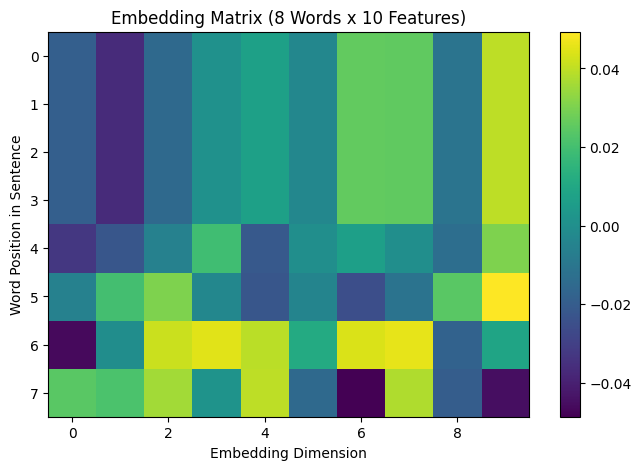

In [21]:
# ===============================
# Get 3D Embedding Tensor
# ===============================

import numpy as np
import matplotlib.pyplot as plt

# Get embeddings for all sentences
embedding_output = model.predict(embedded_docs)

# Print full tensor shape (Batch, Sentence Length, Embedding Dim)
print("Full 3D Tensor Shape:", embedding_output.shape)
print("\n")

# ===============================
# View One Sentence (2D slice)
# ===============================

sentence_1 = embedding_output[0]
print("First Sentence Shape (8 words x 10 features):", sentence_1.shape)
print(sentence_1)
print("\n")

# ===============================
# View One Word Vector
# ===============================

word_vector = embedding_output[0][4]   # 5th word of first sentence
print("Single Word Vector Shape:", word_vector.shape)
print(word_vector)
print("\n")

# ===============================
# View Two Word Vectors
# ===============================

two_words = embedding_output[0][4:6]   # Words 5 and 6
print("Two Word Vectors Shape:", two_words.shape)
print(two_words)
print("\n")

# ===============================
# Keep 3D Format (Single Sentence)
# ===============================

single_sentence_3D = embedding_output[0:1]
print("Single Sentence in 3D Format Shape:", single_sentence_3D.shape)
print("\n")

# ===============================
# Visualize Embedding Matrix as Heatmap
# ===============================

plt.figure(figsize=(8,5))
plt.imshow(sentence_1, cmap='viridis')
plt.colorbar()
plt.title("Embedding Matrix (8 Words x 10 Features)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Word Position in Sentence")
plt.show()

Embedding Matrix Shape: (500, 10)


Word Indices: [300 361 448 211]


Word Vectors Shape: (4, 10)
[[-3.2815874e-02 -2.2398544e-02 -5.5799857e-03  1.9206014e-02
  -2.1190632e-02 -1.0390207e-04  6.7711361e-03 -6.7152083e-05
  -1.3360478e-02  3.0456629e-02]
 [-5.6377873e-03  2.0189773e-02  3.0384410e-02 -3.2055750e-03
  -2.2289265e-02 -4.3820627e-03 -2.4937427e-02 -1.1313118e-02
   2.4207402e-02  4.9346987e-02]
 [-4.6266615e-02 -7.2642416e-04  4.1474234e-02  4.5038510e-02
   3.9121103e-02  1.1375379e-02  4.3918673e-02  4.5809772e-02
  -1.7791331e-02  8.5216053e-03]
 [ 2.4207402e-02  2.1659326e-02  3.5604659e-02  1.6385913e-03
   3.9635930e-02 -1.5217818e-02 -4.8650969e-02  3.7860703e-02
  -1.9935442e-02 -4.5117307e-02]]


Cosine Similarity Matrix:
[[ 1.0000001   0.21902968  0.32537428 -0.61161107]
 [ 0.21902968  1.0000001  -0.14380878 -0.17804393]
 [ 0.32537428 -0.14380878  1.0000001   0.12215203]
 [-0.61161107 -0.17804393  0.12215203  1.0000001 ]]


Cosine Similarity Between First Two Wo

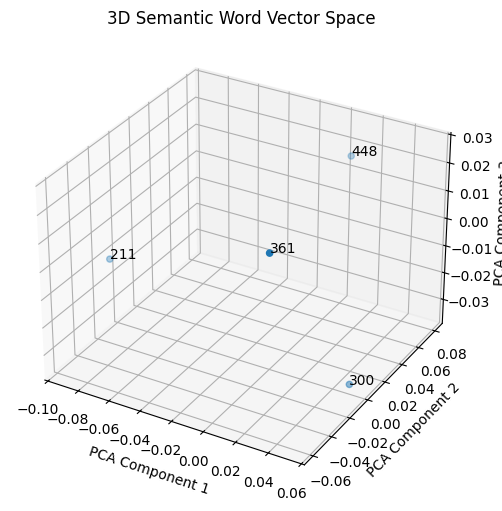

In [22]:
# ============================================
# Semantic Word Vector Representation
# Cosine Similarity + 3D Vector Visualization
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# --------------------------------------------
# Step 1: Get embedding matrix from model
# --------------------------------------------

embedding_layer = model.layers[0]
embedding_matrix = embedding_layer.get_weights()[0]  # Shape: (voc_size, 10)

print("Embedding Matrix Shape:", embedding_matrix.shape)
print("\n")

# --------------------------------------------
# Step 2: Select words from first sentence
# --------------------------------------------

# Get word indices of first sentence (non-zero only)
word_indices = embedded_docs[0]
word_indices = word_indices[word_indices != 0]

print("Word Indices:", word_indices)
print("\n")

# Get corresponding word vectors
word_vectors = embedding_matrix[word_indices]

print("Word Vectors Shape:", word_vectors.shape)
print(word_vectors)
print("\n")

# --------------------------------------------
# Step 3: Cosine Similarity Between Words
# --------------------------------------------

similarity_matrix = cosine_similarity(word_vectors)

print("Cosine Similarity Matrix:")
print(similarity_matrix)
print("\n")

# Example: Similarity between first two real words
if len(word_vectors) >= 2:
    sim_value = cosine_similarity(
        word_vectors[0].reshape(1, -1),
        word_vectors[1].reshape(1, -1)
    )
    print("Cosine Similarity Between First Two Words:", sim_value[0][0])
    print("\n")

# --------------------------------------------
# Step 4: Reduce 10D → 3D using PCA
# --------------------------------------------

pca = PCA(n_components=3)
word_vectors_3D = pca.fit_transform(word_vectors)

print("3D Vector Representation Shape:", word_vectors_3D.shape)
print(word_vectors_3D)
print("\n")

# --------------------------------------------
# Step 5: 3D Visualization
# --------------------------------------------

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = word_vectors_3D[:, 0]
y = word_vectors_3D[:, 1]
z = word_vectors_3D[:, 2]

ax.scatter(x, y, z)

for i, idx in enumerate(word_indices):
    ax.text(x[i], y[i], z[i], str(idx))

ax.set_title("3D Semantic Word Vector Space")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

plt.show()

Computes Cosine Similarity:

Formula used internally:
(cos)cosine_similarity(A,B)=A⋅B/ (∣∣A∣∣ x ∣∣B∣∣)


Range:

    +1 → very similar
    0 → unrelated
    -1 → opposite
